In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs

import sys
module_path = "../bin"
sys.path.insert(0, module_path)

import um_utils_plotting as umplt
import um_utils as um
import get_cpt
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

np.set_printoptions(suppress=True)

um.WarningSuppress()

In [4]:
#------------------------------------------------------------
# Import UKESM Simulated Climate
#------------------------------------------------------------

MH_means = um.importUMData(f"../Data/Models/Monthly_Means/MH_monthly_means_197001-204912.nc")
PI_means = um.importUMData(f"../Data/Models/Monthly_Means/PI_monthly_means_187001-194912.nc")

ukesm_pr = (MH_means["pr"] - PI_means["pr"]) * 12 # Convert to mm/yr
ukesm_tas = MH_means["tas"] - PI_means["tas"]

#------------------------------------------------------------
# Import Bartlein Pollen Reconstructions
#------------------------------------------------------------

bart_dir = "/Users/ajw1g19/Library/CloudStorage/OneDrive-UniversityofSouthampton/INSPIRE DTP/Projects/Palaeo-Proxies/Bartlein"
BART_MAT = um.importUMData(f"{bart_dir}/mat_delta_06ka_ALL_grid_2x2_ex.nc") 
BART_MAP = um.importUMData(f"{bart_dir}/map_delta_06ka_ALL_grid_2x2_ex.nc")

bart_mat = BART_MAT["mat_anm_mean"].stack(points=("lat", "lon")).dropna("points")
bart_map = BART_MAP["map_anm_mean"].stack(points=("lat", "lon")).dropna("points")

#------------------------------------------------------------
# Import Legacy Climate Reconstructions
#------------------------------------------------------------

LC_anoms_df = pd.read_excel(f"../Data/Proxies/LC_climate_reconstruction_anomalies.xlsx")
LC_anoms_df = LC_anoms_df[LC_anoms_df["Continent"].isin(["Western North America", "Eastern North America"])]

LC_lat = LC_anoms_df["Latitude"].values
LC_lon = LC_anoms_df["Longitude"].values

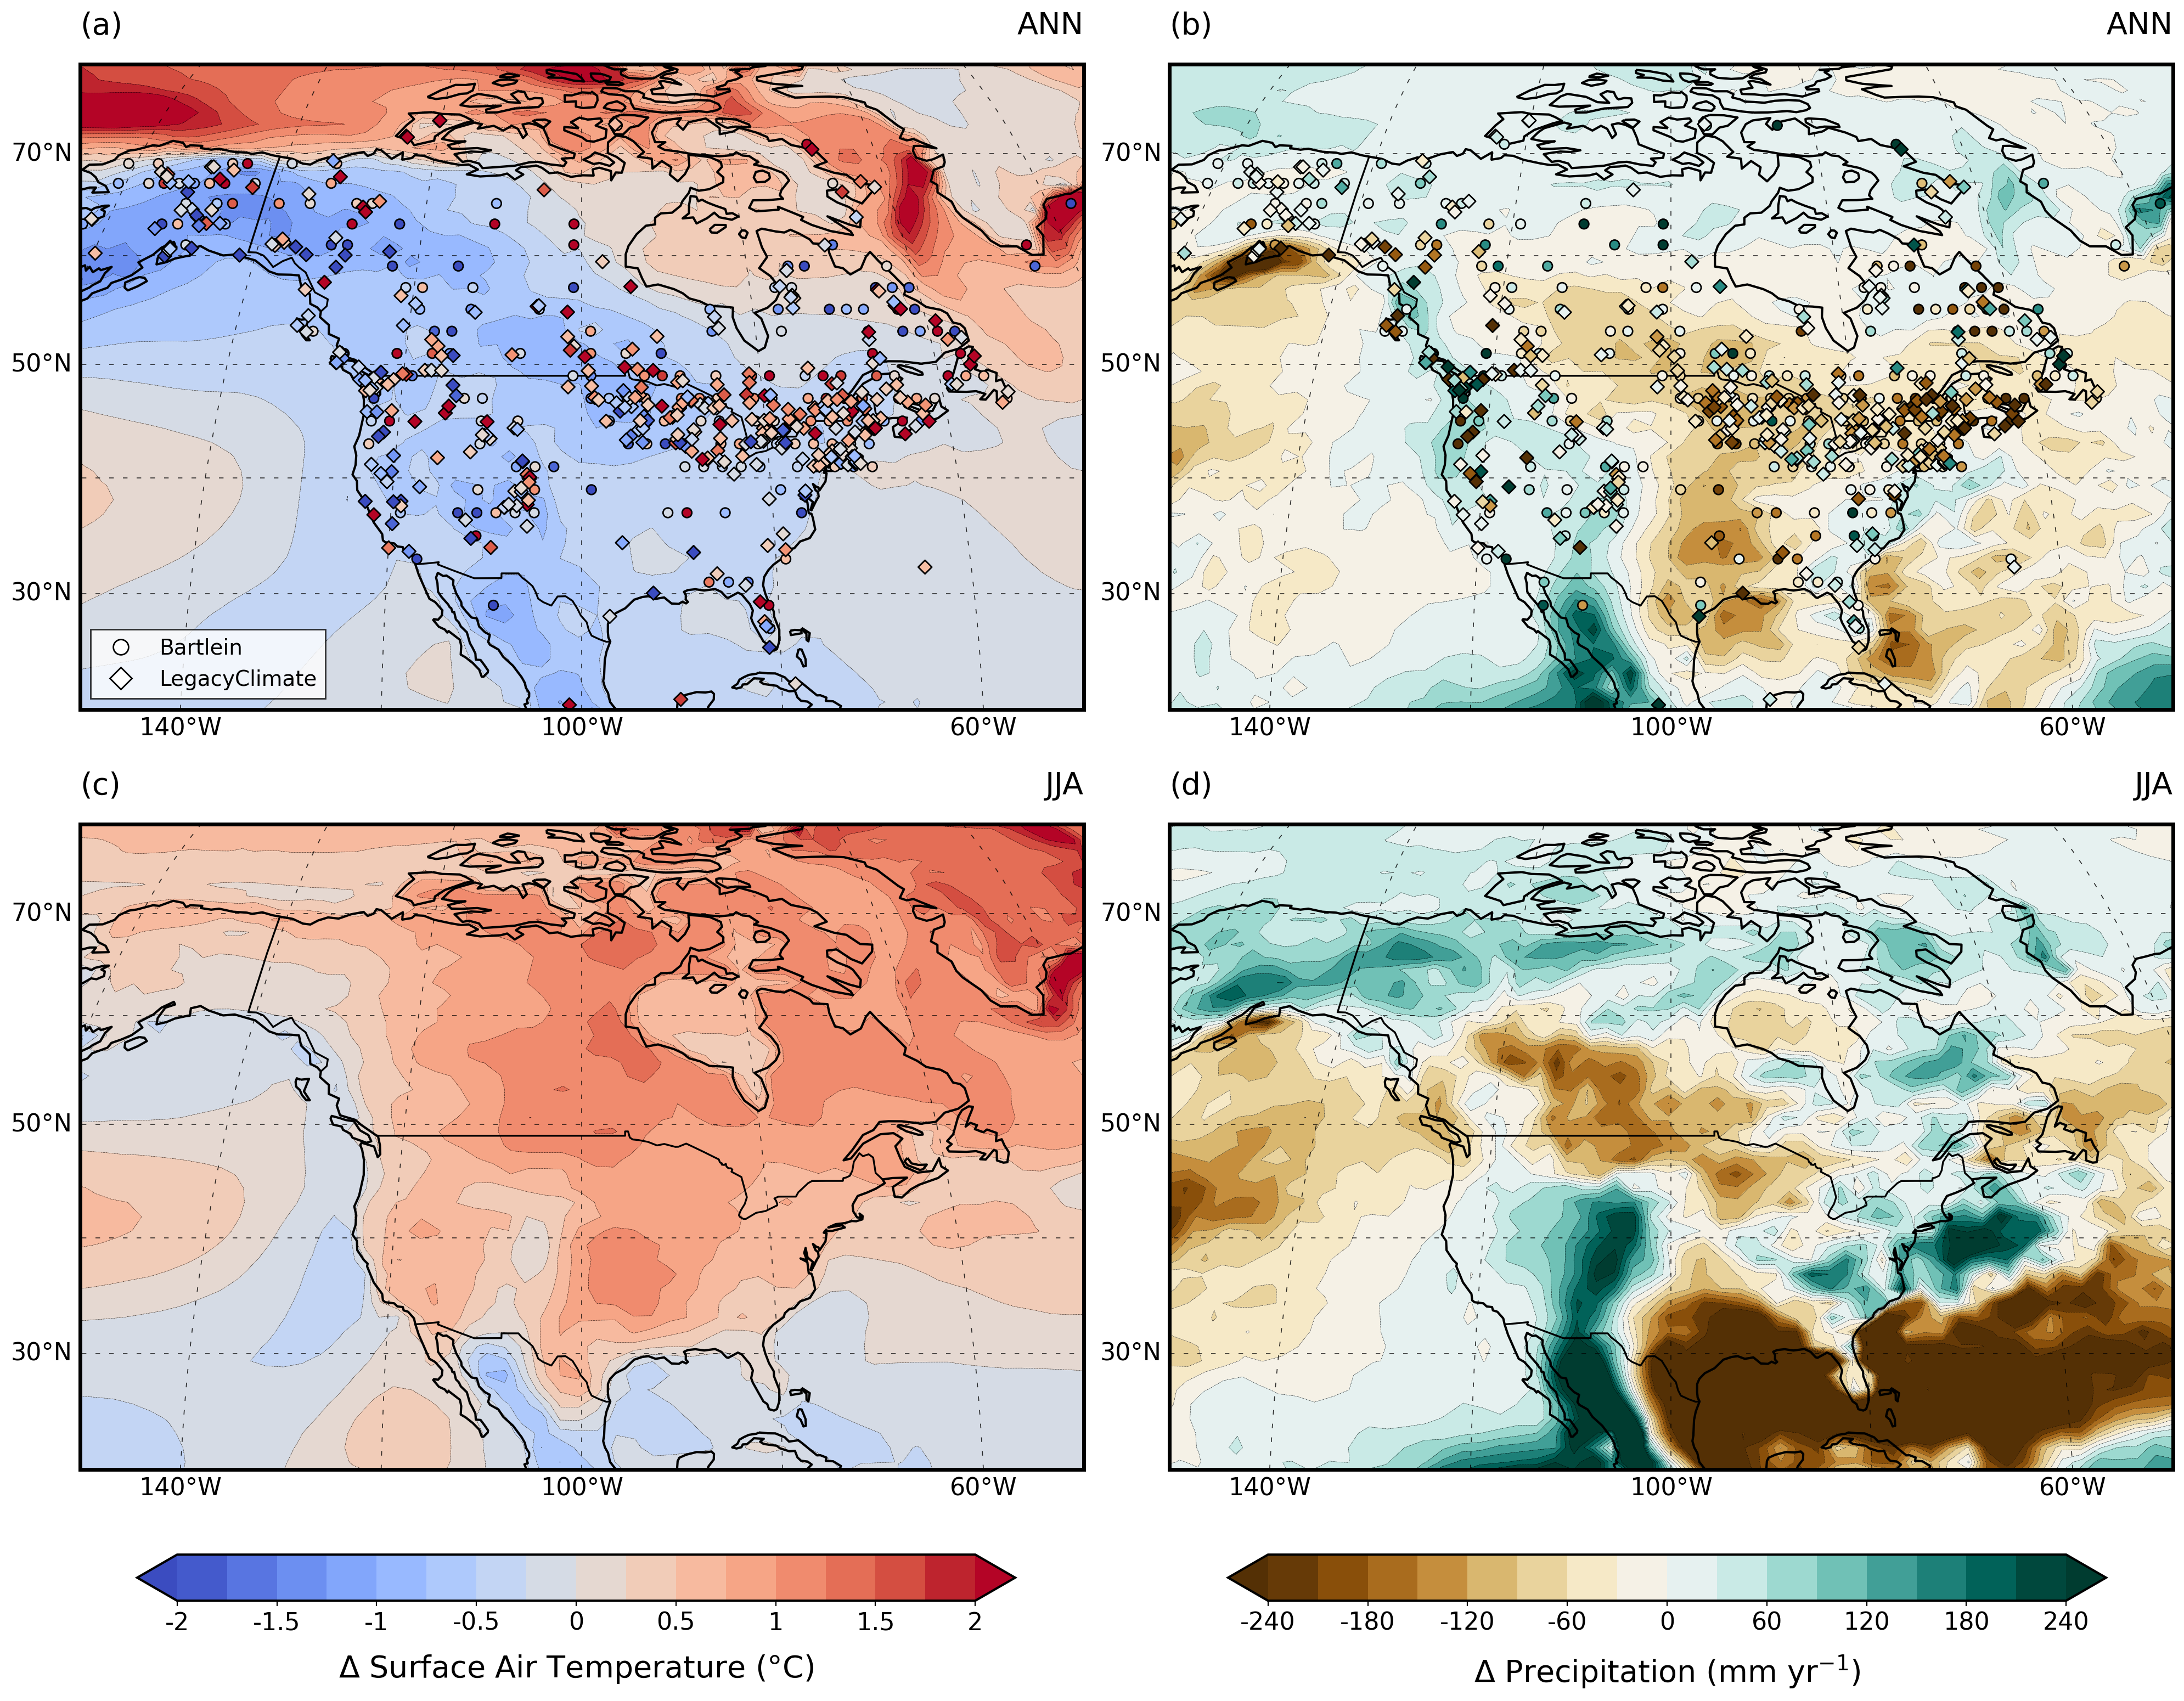

In [5]:
#------------------------------------------------------------
# Plot Figure
#------------------------------------------------------------

vars = ["tas", "pr"]
labels = np.array([["a", "b"], ["c", "d"]])

fig = plt.figure(figsize = (20, 14), dpi=200)
gs = gridspec.GridSpec(2, 2)

lims, proj = [-150, -50, 20, 80], ccrs.Robinson(central_longitude=-100)
LON, LAT = np.meshgrid(MH_means.longitude, MH_means.latitude)

for j, var in enumerate(vars):

    #------------------------------------------------------------
    # Properties for Tas plots
    #------------------------------------------------------------

    if var == "tas":
        cmap = cm.coolwarm; v = 2; levs = np.linspace(-v, v, 17); cbar_lab = r"$\Delta$ Surface Air Temperature (°C)"
        norm = BoundaryNorm(levs, cmap.N, extend="both")
        cbaxes = fig.add_axes((0.065, -0.05, 0.4, 0.03))

        ukesm_var = ukesm_tas
        ax = plt.subplot(gs[0, 0], projection=proj)
        ax2 = plt.subplot(gs[1, 0], projection=proj)

        BART = bart_mat.values
        bart_lon = bart_mat.lon
        bart_lat = bart_mat.lat
        LC = LC_anoms_df["T air (annual mean) [°C] (MAT)"].values

    #------------------------------------------------------------
    # Properties for Pr plots
    #------------------------------------------------------------

    elif var == "pr":
        cmap = cm.BrBG; v = 240; levs = np.linspace(-v, v, 17); cbar_lab = r"$\Delta$ Precipitation (mm $\mathregular{yr^{-1}}$)"
        norm = BoundaryNorm(levs, cmap.N, extend="both")
        cbaxes = fig.add_axes((0.562, -0.05, 0.4, 0.03))

        ukesm_var = ukesm_pr
        ax = plt.subplot(gs[0, 1], projection=proj)
        ax2 = plt.subplot(gs[1, 1], projection=proj)

        BART = bart_map.values
        bart_lon = bart_map.lon
        bart_lat = bart_map.lat

        LC = LC_anoms_df["Precip annual total [mm/a] (MAT)"].values

    #------------------------------------------------------------
    # Plot Annual Means
    #------------------------------------------------------------
    
    umplt.plotBaseMap(ax, lims, coastlw=1.5, spinelw=2.5, bordercol="black", borderlw=1.2)
    umplt.plotGrid(ax, xlabeledlines=[-60,-100,-140], ylabeledlines=[30,50,70], xlines=[-40,-80,-120,-160], ylines=[40,60],
                   labelsize=16, lw=0.6)

    cf1 = ax.contourf(LON, LAT, ukesm_var.mean(dim="time"), extend="both", levels=levs, cmap=cmap, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)
    c1 = ax.contour(LON, LAT, ukesm_var.mean(dim="time"), extend="both", levels=levs, colors="black", linestyles="dashed", linewidths=0.2, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)

    p1 = ax.scatter(bart_lon, bart_lat, c=BART, s=40, marker="o", cmap=cmap, norm=norm, edgecolors="black", linewidths=1, transform=ccrs.PlateCarree(), zorder=2)
    p2 = ax.scatter(LC_lon, LC_lat, c=LC, s=40, marker="D", cmap=cmap, norm=norm, edgecolors="black", linewidths=1, transform=ccrs.PlateCarree(), zorder=2)

    ax.set_title("(" + labels[0, j] + ")", loc="left", fontsize=20, pad=20)
    ax.set_title("ANN", loc="right", fontsize=20, pad=20)

    #------------------------------------------------------------
    # Plot Summer (JJA) Means
    #------------------------------------------------------------

    umplt.plotBaseMap(ax2, lims, coastlw=1.5, spinelw=2.5, bordercol="black", borderlw=1.2)
    umplt.plotGrid(ax2, xlabeledlines=[-60,-100,-140], ylabeledlines=[30,50,70], xlines=[-40,-80,-120,-160], ylines=[40,60],
                   labelsize=16, lw=0.6)
    
    ax2.contourf(LON, LAT, ukesm_var.isel(time=[5, 6, 7]).mean(dim="time"), extend="both", levels=levs, cmap=cmap, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)
    ax2.contour(LON, LAT, ukesm_var.isel(time=[5, 6, 7]).mean(dim="time"), extend="both", levels=levs, colors="black", linestyles="dashed", linewidths=0.2, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)    

    cbar = plt.colorbar(cf1, extend='both', orientation='horizontal', ticks=np.linspace(-v,v,9), cax=cbaxes)
    cbar.outline.set_linewidth(1.5)
    cbar.set_ticks(np.linspace(-v, v, 9),labels=["{:g}".format(x) for x in cbar.get_ticks()], fontsize=16)
    cbar.set_label(label=cbar_lab, size=20, labelpad=12)

    ax2.set_title("(" + labels[1, j] + ")", loc="left", fontsize=20, pad=20)
    ax2.set_title("JJA", loc="right", fontsize=20, pad=20)

    if var == "tas":
        point1 = Line2D([0], [0], marker='o', ms=10, mec='k', mfc='white', ls='')
        point2 = Line2D([0],[0], marker='D', ms=10, mec='k', mfc='white', ls='')
        lgd = ax.legend([point1, point2], ["Bartlein", "LegacyClimate"], loc="lower left", fancybox=False, edgecolor="k", fontsize=14)
        lgd.get_frame().set_linewidth(1)

plt.tight_layout()
plt.show()